# 03 - Pre-trends and power

The decisive notebook. It answers two questions **before** any treatment effect is
estimated, so the specification cannot be chosen to suit the result:

1. **Is the parallel-trends assumption defensible?** Notebook 02 showed the fee-state and
   never-treated group lines converging by roughly 8 index points across 1998-2005. Here
   that is tested formally, without the 2005 normalisation that flattered the picture.
2. **Could this design detect a plausible effect at all?** With 7 treated and 9 comparison
   states the minimum detectable effect may exceed any effect the fees plausibly had. A
   null result means nothing unless the MDE is small enough to make it informative
   (`DESIGN.md` 7.1).

A pre-trend test is an **identification diagnostic, not a proof** (`DESIGN.md` 7). It can
falsify the design; it cannot confirm it.

In [15]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

def find_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / "data" / "processed" / "panel.parquet").exists():
            return cand
    raise FileNotFoundError("panel.parquet not found. Run: py src/build_panel.py")

ROOT = find_root(); sys.path.insert(0, str(ROOT))
FIG = ROOT / "results" / "figures"; TAB = ROOT / "results" / "tables"
FIG.mkdir(parents=True, exist_ok=True); TAB.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (11, 5.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

panel = pd.read_parquet(ROOT / "data" / "processed" / "panel.parquet")

OUTCOME   = "first_years_location"
LOG       = "log_fy"
FIRST_FEE = 2006          # first winter semester with any state charging
WINDOW_END = 2007         # last semester before the first abolition (Hessen WS 2008/09)

panel[LOG] = np.log(panel[OUTCOME])
pre = panel[panel.year < FIRST_FEE].copy()

print(f"pre-treatment window: {pre.year.min()}-{pre.year.max()} "
      f"({pre.year.nunique()} winter semesters, {pre.state.nunique()} states)")
print(f"introduction window : {panel.year.min()}-{WINDOW_END}")

pre-treatment window: 1998-2005 (8 winter semesters, 16 states)
introduction window : 1998-2007


## 1. Why the outcome is logged

State sizes differ 20-fold, so a fee effect of a given *percentage* is a very different
number of students in Nordrhein-Westfalen than in Saarland. Working in logs makes the
coefficient a proportional effect and stops the large states dominating.

In [16]:
chk = panel[panel.year == 2005][["state", OUTCOME, LOG]].sort_values(OUTCOME)
print(chk.to_string(index=False, float_format=lambda x: f"{x:12.3f}"))

                 state  first_years_location       log_fy
              Saarland                  3410        8.134
                Bremen                  5129        8.543
Mecklenburg-Vorpommern                  5700        8.648
           Brandenburg                  6840        8.831
    Schleswig-Holstein                  6853        8.832
        Sachsen-Anhalt                  7806        8.963
               Hamburg                  8416        9.038
            Thueringen                  8553        9.054
       Rheinland-Pfalz                 12152        9.405
                Berlin                 15840        9.670
               Sachsen                 18316        9.816
         Niedersachsen                 22250       10.010
                Hessen                 25000       10.127
    Baden-Wuerttemberg                 39979       10.596
                Bayern                 45809       10.732
   Nordrhein-Westfalen                 67786       11.124


## 2. Formal pre-trend test

Restricted to the pre-treatment period only (through WS 2005/06), so nothing here can be
influenced by the treatment itself.

The specification is `log(first_years) ~ t + t:fee_state + state fixed effects`, with
standard errors clustered by state. The `t:fee_state` coefficient **is** the differential
pre-trend: the annual difference in growth rate between states that would later charge fees
and those that never did. The main effect of `fee_state` is absorbed by the state fixed
effects, so only the interaction is identified.

Under parallel trends this coefficient is zero.

In [17]:
def pretrend(df, label, start=None):
    d = df if start is None else df[df.year >= start]
    d = d.copy()
    d["t"] = d["year"] - d["year"].min()
    d["fee_state"] = d["ever_treated"]
    m = smf.ols(f"{LOG} ~ t + t:fee_state + C(state_code)", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["state_code"]})
    b, se = m.params["t:fee_state"], m.bse["t:fee_state"]
    return {"spec": label, "pre_yrs": d.year.nunique(), "n": len(d),
            "slope_pp_per_yr": 100 * b, "se_pp": 100 * se,
            "t": b / se, "p": m.pvalues["t:fee_state"]}

rows = [
    pretrend(pre, "all states, 1998-2005"),
    pretrend(pre, "all states, 2000-2005", start=2000),
    pretrend(pre, "all states, 2002-2005", start=2002),
    pretrend(pre[pre.east == 0], "west only, 1998-2005"),
    pretrend(pre[~pre.state_code.isin(["02", "04", "11"])], "excl. city-states, 1998-2005"),
]
pt = pd.DataFrame(rows)
pt["verdict"] = np.where(pt["p"] < 0.10, "PRE-TREND", "ok")
print("H0: no differential pre-trend between fee states and never-treated states")
print("slope is in percentage points of annual growth\n")
print(pt.to_string(index=False, float_format=lambda x: f"{x:10.3f}"))
pt.to_csv(TAB / "03_pretrend_tests.csv", index=False)

H0: no differential pre-trend between fee states and never-treated states
slope is in percentage points of annual growth

                        spec  pre_yrs   n  slope_pp_per_yr      se_pp          t          p verdict
       all states, 1998-2005        8 128            0.502      0.688      0.729      0.466      ok
       all states, 2000-2005        6  96            0.742      0.859      0.863      0.388      ok
       all states, 2002-2005        4  64           -0.553      1.154     -0.480      0.632      ok
        west only, 1998-2005        8  80           -0.388      1.185     -0.328      0.743      ok
excl. city-states, 1998-2005        8 104            0.691      0.550      1.258      0.209      ok


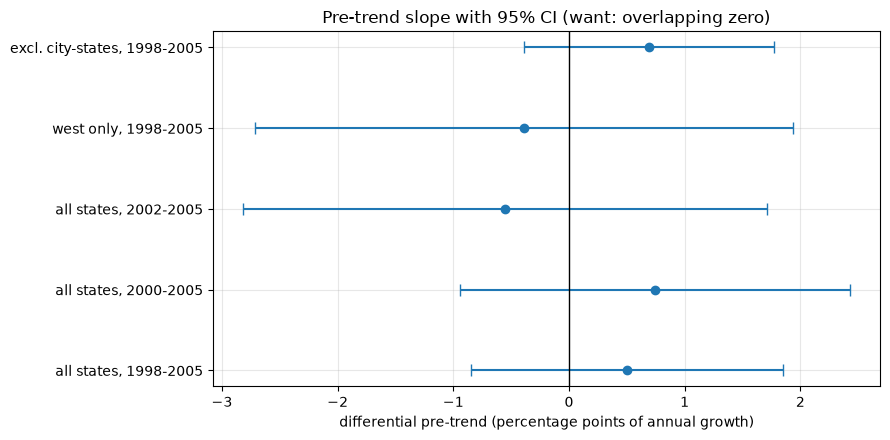

In [18]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(pt))
ax.errorbar(pt["slope_pp_per_yr"], y, xerr=1.96 * pt["se_pp"], fmt="o", capsize=4)
ax.axvline(0, color="black", lw=1)
ax.set_yticks(y); ax.set_yticklabels(pt["spec"])
ax.set_xlabel("differential pre-trend (percentage points of annual growth)")
ax.set_title("Pre-trend slope with 95% CI (want: overlapping zero)")
plt.tight_layout()
plt.savefig(FIG / "07_pretrend_tests.png", dpi=130, bbox_inches="tight")
plt.show()

**Reading it.** A slope of +1 means fee states were growing 1 percentage point per year
faster than the comparison group *before any fee existed*. A `PRE-TREND` verdict means
parallel trends is in doubt for that specification, and any DiD estimate built on it
inherits that doubt.

Fewer pre-years means less power, so an "ok" from a short window is weak evidence rather
than reassurance.

## 3. Unnormalised group means

Notebook 02 indexed both groups to 2005, which forces the gap to zero in that year and
makes the pre-period look flatter than it is. Here the log difference is plotted with no
normalisation.

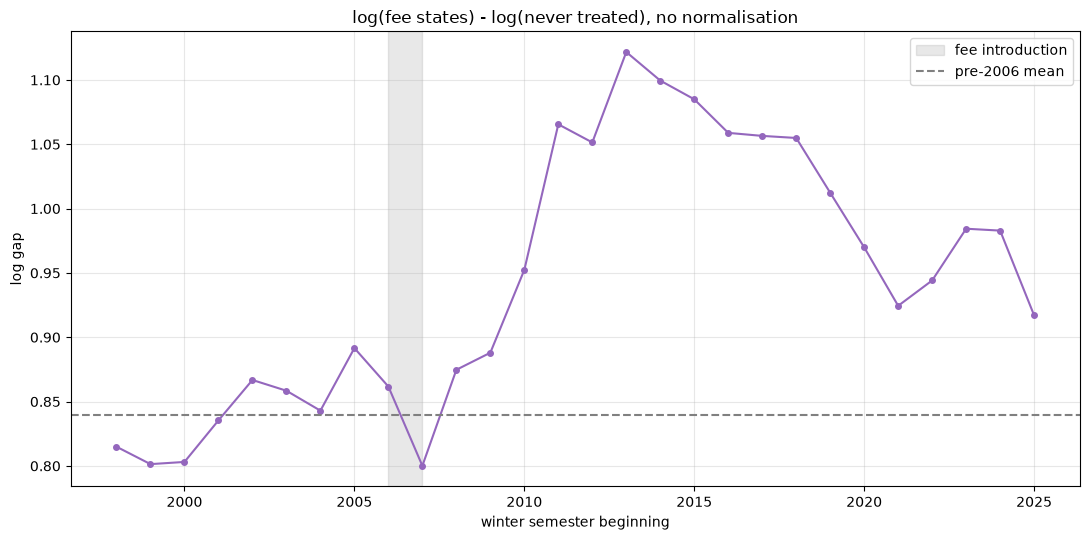

pre-2006 log gap: mean 0.8393, sd 0.0321
fitted slope    : +1.121 pp per year


In [19]:
g = (panel.assign(grp=np.where(panel.ever_treated == 1, "fee", "never"))
     .groupby(["grp", "year"], as_index=False)[OUTCOME].sum())
g["log"] = np.log(g[OUTCOME])
piv = g.pivot(index="year", columns="grp", values="log")
piv["log_gap"] = piv["fee"] - piv["never"]

fig, ax = plt.subplots()
ax.plot(piv.index, piv["log_gap"], marker="o", ms=4, color="tab:purple")
ax.axvspan(FIRST_FEE, WINDOW_END, color="grey", alpha=0.18, label="fee introduction")
pre_mean = piv.loc[:FIRST_FEE - 1, "log_gap"].mean()
ax.axhline(pre_mean, color="grey", ls="--", label="pre-2006 mean")
ax.set_title("log(fee states) - log(never treated), no normalisation")
ax.set_xlabel("winter semester beginning"); ax.set_ylabel("log gap")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "08_log_gap.png", dpi=130, bbox_inches="tight")
plt.show()

pre_gap = piv.loc[:FIRST_FEE - 1, "log_gap"]
slope = np.polyfit(pre_gap.index, pre_gap.values, 1)[0]
print(f"pre-2006 log gap: mean {pre_gap.mean():.4f}, sd {pre_gap.std():.4f}")
print(f"fitted slope    : {100*slope:+.3f} pp per year")

## 4. Minimum detectable effect

Computed from the **pre-period** residual variation after removing state and year effects,
which is the noise a DiD actually has to overcome. Reported per comparison group, because
the western-only group has 3 controls and the pooled group has 9 (`DESIGN.md` 5.2).

The formula is the standard two-group MDE at 5% significance and 80% power. It is an
approximation, not an exact power calculation for Callaway-Sant'Anna, and is used to
establish the order of magnitude of what this design can see.

In [20]:
from scipy import stats

def residual_sd(df):
    """SD of log outcome after absorbing state and year effects."""
    m = smf.ols(f"{LOG} ~ C(state_code) + C(year)", data=df).fit()
    return float(np.std(m.resid, ddof=1))

WEST_NEVER = ["01", "04", "07"]   # Schleswig-Holstein, Bremen, Rheinland-Pfalz

def mde(df, label, n_post, alpha=0.05, power=0.80):
    sd = residual_sd(df)
    n_t = df.loc[df.ever_treated == 1, "state_code"].nunique()
    n_c = df.loc[df.ever_treated == 0, "state_code"].nunique()
    n_pre = df.year.nunique()
    # effective SE of a DiD contrast with n_pre pre and n_post post periods
    se = sd * np.sqrt((1 / n_t + 1 / n_c) * (1 / n_pre + 1 / n_post))
    z = stats.norm.ppf(1 - alpha / 2) + stats.norm.ppf(power)
    return {"comparison group": label, "treated": n_t, "controls": n_c,
            "pre_periods": n_pre, "post_periods": n_post,
            "resid_sd_log": sd, "MDE_log": z * se, "MDE_%": 100 * (np.exp(z * se) - 1)}

N_POST = WINDOW_END - FIRST_FEE + 1        # 2006 and 2007
rows = [
    mde(pre, "all never-treated (9)", N_POST),
    mde(pre[(pre.ever_treated == 1) | (pre.state_code.isin(WEST_NEVER))],
        "western never-treated (3)", N_POST),
    mde(pre[~pre.state_code.isin(["02", "04", "11"])], "excl. city-states", N_POST),
]
m = pd.DataFrame(rows)
print(f"introduction window has {N_POST} post-treatment winter semesters\n")
print(m.to_string(index=False, float_format=lambda x: f"{x:10.3f}"))
m.to_csv(TAB / "03_mde.csv", index=False)

introduction window has 2 post-treatment winter semesters

         comparison group  treated  controls  pre_periods  post_periods  resid_sd_log    MDE_log      MDE_%
    all never-treated (9)        7         9            8             2         0.048      0.053      5.451
western never-treated (3)        7         3            8             2         0.039      0.060      6.148
        excl. city-states        6         7            8             2         0.043      0.053      5.406


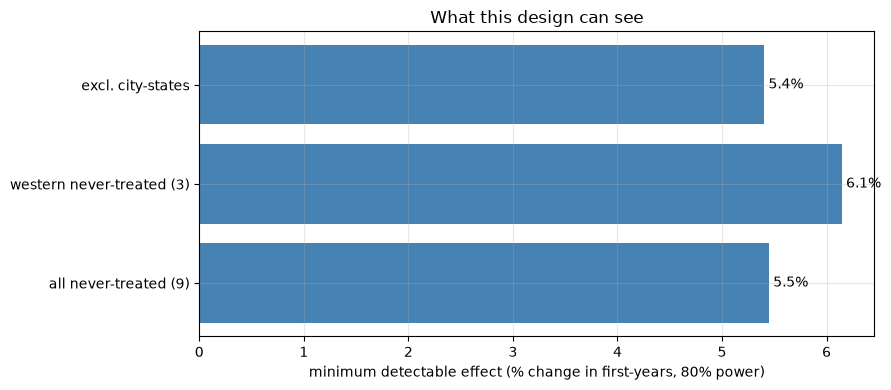

For reference, the raw first-semester falls observed in notebook 02:
  Nordrhein-Westfalen WS 2006/07: -6.6%
  Hessen WS 2006/07 (announcement): -5.2%

If the MDE exceeds these, the design cannot detect effects of the size
actually claimed in the public debate, and a null would be uninformative.


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(m["comparison group"], m["MDE_%"], color="steelblue")
for i, val in enumerate(m["MDE_%"]):
    ax.text(val, i, f" {val:.1f}%", va="center")
ax.set_xlabel("minimum detectable effect (% change in first-years, 80% power)")
ax.set_title("What this design can see")
plt.tight_layout()
plt.savefig(FIG / "09_mde.png", dpi=130, bbox_inches="tight")
plt.show()

print("For reference, the raw first-semester falls observed in notebook 02:")
print("  Nordrhein-Westfalen WS 2006/07: -6.6%")
print("  Hessen WS 2006/07 (announcement): -5.2%")
print("\nIf the MDE exceeds these, the design cannot detect effects of the size")
print("actually claimed in the public debate, and a null would be uninformative.")

## 5. Specification decision

### Pre-trends: no violation detected, but the test is weak

All five specifications fail to reject the null of no differential pre-trend:

| specification | slope (pp/yr) | se | p | verdict |
|---|---|---|---|---|
| all states, 1998-2005 | +0.50 | 0.69 | 0.47 | ok |
| all states, 2000-2005 | +0.74 | 0.86 | 0.39 | ok |
| all states, 2002-2005 | -0.55 | 1.15 | 0.63 | ok |
| west only, 1998-2005 | -0.39 | 1.19 | 0.74 | ok |
| excl. city-states, 1998-2005 | +0.69 | 0.55 | 0.21 | ok |

**This is weak reassurance, not clearance.** The standard errors run 0.55 to 1.19
percentage points per year, so the 95% interval on the headline specification spans roughly
-0.85 to +1.85 pp per year. A differential trend at the upper end, sustained across the two
post-treatment semesters, would shift the estimate by about 2.8 percentage points, which is
around half the effect the design can detect at all. The test cannot rule out a trend large
enough to matter. Per `DESIGN.md` 7, this is an identification diagnostic that has failed to
falsify the design, not evidence that the assumption holds.

**Two measures of the pre-trend disagree, and the regression is the right one.** The
unnormalised log-gap plot fits +1.12 pp per year, against +0.50 from the regression. The
gap is computed on group *sums*, so it is dominated by Nordrhein-Westfalen and Bayern, while
the regression weights every state equally through state fixed effects. Since both TWFE and
Callaway-Sant'Anna weight states rather than students, +0.50 is the relevant figure. The
larger number is reported alongside it as a reminder that the answer is sensitive to
weighting.

### Power: the binding constraint

| comparison group | treated | controls | residual sd (log) | MDE |
|---|---|---|---|---|
| all never-treated | 7 | 9 | 0.048 | **5.5%** |
| excluding city-states | 6 | 7 | 0.043 | **5.4%** |
| western never-treated | 7 | 3 | 0.039 | **6.1%** |

Set against the raw first-semester falls from notebook 02:

- Nordrhein-Westfalen **-6.6%**: above the threshold, detectable.
- Hessen **-5.2%**: below the threshold, **not detectable**.

So the design can identify a large effect and cannot identify a moderate one. This is
committed to in advance: **if estimation returns a null, it is uninformative for effects
below roughly 5.5%, and will be reported that way rather than as evidence of no effect.**

### Decisions carried into notebook 04

1. **Primary comparison group: all nine never-treated states.** It has the best power
   (5.5%, effectively tied with excluding city-states at 5.4%) and the largest sample. The
   western-only group is reported alongside it despite worse power, per `DESIGN.md` 5.2,
   and a result that survives in only one grouping is described as fragile.
2. **Outcome: log first-years by study location.** Logs because state sizes differ 20-fold.
   Normalising by the Abitur cohort was considered and rejected: it would divide two
   different populations, since students enrolled in a state did not all attend school
   there, so the ratio would measure inflow per local school leaver rather than enrolment
   propensity. That normalisation belongs to the home-state outcome in phase 2.
3. **Window: 1998 to 2007**, ending before the first abolition so treatment is absorbing
   and Callaway-Sant'Anna is valid (`DESIGN.md` 2).
4. **Inference: wild cluster bootstrap alongside analytic clustered errors.** With 16
   clusters the asymptotic approximation is unreliable; the bootstrap is expected to widen
   the intervals rather than narrow them, which is the point.
5. **Sachsen-Anhalt sensitivity is mandatory.** Its double cohort falls in 2007 in the
   control group (notebook 01), so the estimate is produced with it, without it, and with a
   double-cohort control.
6. **Test for anticipation.** Hessen fell 5.2% the semester fees were announced rather than
   charged, so event-study leads are examined for a pre-treatment response and an
   anticipation-adjusted specification is reported.

Next: `04_estimation.ipynb`, with the specification above fixed.